In [1]:
# Import core libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Import preprocessing and pipeline utilities
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV

# Import classification models and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Import regression models and metrics
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Set a clean plot style for better-looking visuals
sns.set_theme(style="whitegrid")

In [3]:
# ==========================================
# Task 1.1 & 1.2: Load and Inspect the Data
# ==========================================

# Load the dataset from CSV file
df = pd.read_csv('bus_operations.csv')  # Adjust filename if yours is different

# Quick peek at the first 5 rows to understand what one trip record looks like
print("--- First 5 rows of the dataset ---")
display(df.head())

# Check dataset shape (number of rows and columns)
print(f"\nDataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

# Summary of column data types and non-null counts
print("\n--- Data Overview & Types ---")
df.info()

# Summary statistics for numerical variables
print("\n--- Summary Statistics (Numerical) ---")
display(df.describe())

# Check for missing values across all columns
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Check for exact duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()
print(f"\nExact duplicate rows count: {duplicate_rows}")




--- First 5 rows of the dataset ---


,trip_id,weather_condition,bus_type,traffic_level,distance_km,num_stops,passenger_count,driver_experience_years,scheduled_duration_minutes,trip_duration_minutes,delay_level
0,TRIP_10000,Clear,Electric,Moderate,37.76,28.0,11,5,128.0,128.1,On-Time
1,TRIP_10001,Snow,Articulated,Moderate,35.11,13.0,75,2,103.4,126.1,Severe-Delay
2,TRIP_10002,Rain,Express,Low,27.09,7.0,69,23,76.1,83.2,Slight-Delay
3,TRIP_10003,NaN,Articulated,Moderate,43.15,23.0,26,1,135.5,143.1,Slight-Delay
4,TRIP_10004,Clear,Articulated,Moderate,11.42,24.0,25,16,57.4,60.8,On-Time



Dataset Dimensions: 1005 rows, 11 columns

--- Data Overview & Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     1005 non-null   object 
 1   weather_condition           981 non-null    object 
 2   bus_type                    1005 non-null   object 
 3   traffic_level               974 non-null    object 
 4   distance_km                 977 non-null    float64
 5   num_stops                   977 non-null    float64
 6   passenger_count             1005 non-null   int64  
 7   driver_experience_years     1005 non-null   int64  
 8   scheduled_duration_minutes  1005 non-null   float64
 9   trip_duration_minutes       1005 non-null   float64
 10  delay_level                 1005 non-null   object 
dtypes: float64(4), int64(2), object(5)
memory usage: 86.5+ KB

--- Summary St

,distance_km,num_stops,passenger_count,driver_experience_years,scheduled_duration_minutes,trip_duration_minutes
count,977.000000,977.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,24.054330,19.986694,49.944279,12.656716,84.148259,99.905274
std,12.156601,8.417197,22.949123,6.936864,32.110263,33.719515
min,3.000000,5.000000,10.000000,1.000000,15.100000,16.100000
25%,13.520000,13.000000,30.000000,7.000000,57.600000,72.500000
50%,24.440000,20.000000,51.000000,13.000000,85.600000,99.600000
75%,34.430000,27.000000,69.000000,19.000000,110.400000,126.600000
max,44.950000,34.000000,89.000000,24.000000,152.800000,181.500000



--- Missing Values Count ---
trip_id                        0
weather_condition             24
bus_type                       0
traffic_level                 31
distance_km                   28
num_stops                     28
passenger_count                0
driver_experience_years        0
scheduled_duration_minutes     0
trip_duration_minutes          0
delay_level                    0
dtype: int64

Exact duplicate rows count: 5



--- Classification Target: delay_level ---
Slight-Delay: 450 trips (44.78%)
Severe-Delay: 307 trips (30.55%)
On-Time: 248 trips (24.68%)


C:\Users\abdo\AppData\Local\Temp\ipykernel_10460\536102407.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='delay_level', palette='Set2')


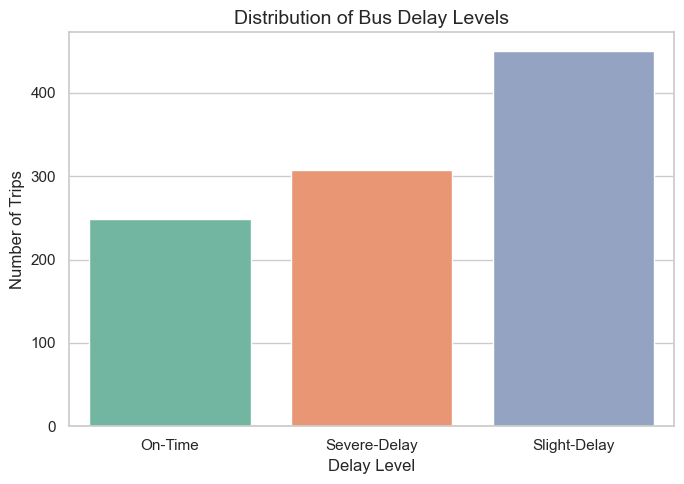

In [4]:
# ==========================================
# Task 1.3: Explore Classification Target (delay_level)
# ==========================================

# Calculate frequency and percentage distribution for delay classes
delay_counts = df['delay_level'].value_counts()
delay_props = df['delay_level'].value_counts(normalize=True) * 100

print("\n--- Classification Target: delay_level ---")
for cls in delay_counts.index:
    print(f"{cls}: {delay_counts[cls]} trips ({delay_props[cls]:.2f}%)")

# Plot distribution of the delay levels
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='delay_level', palette='Set2')
plt.title("Distribution of Bus Delay Levels", fontsize=14)
plt.xlabel("Delay Level", fontsize=12)
plt.ylabel("Number of Trips", fontsize=12)
plt.tight_layout()
plt.show()





--- Regression Target: trip_duration_minutes ---
count    1005.000000
mean       99.905274
std        33.719515
min        16.100000
25%        72.500000
50%        99.600000
75%       126.600000
max       181.500000
Name: trip_duration_minutes, dtype: float64


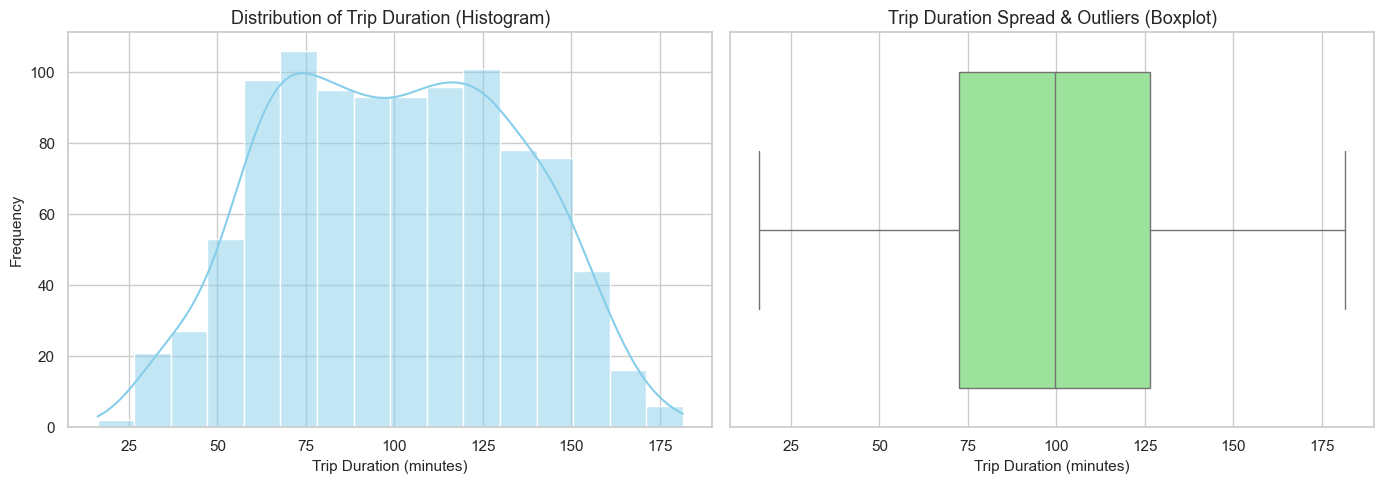

In [5]:
# ==========================================
# Task 1.4: Explore Regression Target (trip_duration_minutes)
# ==========================================

# Summary metrics for trip duration
duration_summary = df['trip_duration_minutes'].describe()
print("\n--- Regression Target: trip_duration_minutes ---")
print(duration_summary)

# Visualizing trip duration with Histogram and Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE to see distribution shape
sns.histplot(df['trip_duration_minutes'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution of Trip Duration (Histogram)", fontsize=13)
axes[0].set_xlabel("Trip Duration (minutes)", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)

# Boxplot to check for outliers and spread
sns.boxplot(x=df['trip_duration_minutes'], ax=axes[1], color='lightgreen')
axes[1].set_title("Trip Duration Spread & Outliers (Boxplot)", fontsize=13)
axes[1].set_xlabel("Trip Duration (minutes)", fontsize=11)

plt.tight_layout()
plt.show()




C:\Users\abdo\AppData\Local\Temp\ipykernel_10460\2756042309.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='traffic_level', y='trip_duration_minutes',


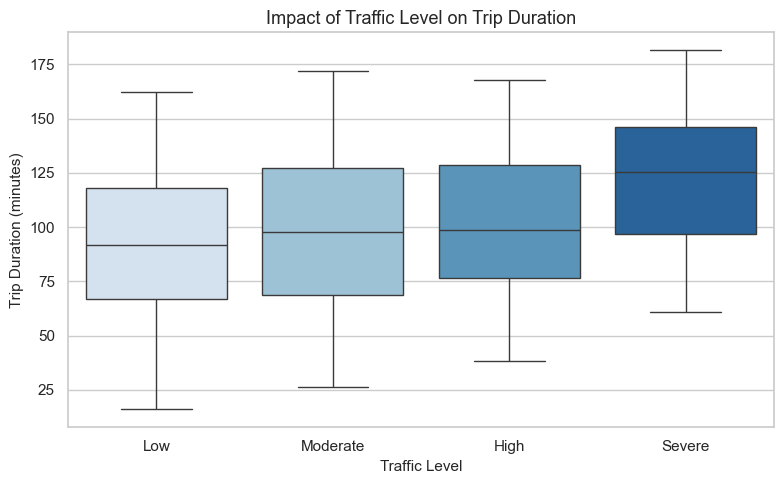

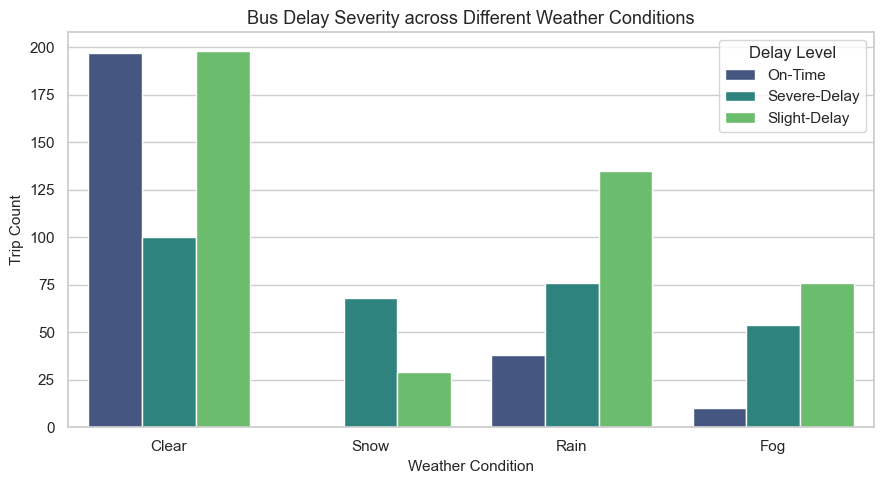

In [6]:
# ==========================================
# Task 1.5: Investigate & Justify Key Relationships
# ==========================================

# Relationship 1: Traffic Level vs Trip Duration (Numerical vs Ordinal)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='traffic_level', y='trip_duration_minutes', 
            order=['Low', 'Moderate', 'High', 'Severe'], palette='Blues')
plt.title("Impact of Traffic Level on Trip Duration", fontsize=13)
plt.xlabel("Traffic Level", fontsize=11)
plt.ylabel("Trip Duration (minutes)", fontsize=11)
plt.tight_layout()
plt.show()

# Relationship 2: Weather Condition vs Delay Level (Categorical vs Categorical)
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='weather_condition', hue='delay_level', palette='viridis')
plt.title("Bus Delay Severity across Different Weather Conditions", fontsize=13)
plt.xlabel("Weather Condition", fontsize=11)
plt.ylabel("Trip Count", fontsize=11)
plt.legend(title="Delay Level")
plt.tight_layout()
plt.show()

In [7]:


# ==========================================
# Task 2.1: Clean & Separate Features/Targets
# ==========================================

# 1. Remove exact duplicate rows from the dataset
df_cleaned = df.drop_duplicates().copy()
print(
    f"Rows after removing duplicates: {len(df_cleaned)} (Removed {len(df) - len(df_cleaned)} duplicates)"
)

# 2. Separate features (X) and both target variables (y_class, y_reg)
# Drop trip_id from features as it's just an identifier, plus both target columns
X = df_cleaned.drop(
    columns=["trip_id", "delay_level", "trip_duration_minutes"]
)

# Classification target (delay_level)
y_class = df_cleaned["delay_level"]

# Regression target (trip_duration_minutes)
y_reg = df_cleaned["trip_duration_minutes"]



Rows after removing duplicates: 1000 (Removed 5 duplicates)


In [8]:

# ==========================================
# Task 2.2: Shared Train/Test Split
# ==========================================

# Split data into Train and Test sets (80/20 ratio)
# We stratify by y_class to preserve class proportions for classification
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = (
    train_test_split(
        X,
        y_class,
        y_reg,
        test_size=0.20,
        random_state=42,
        stratify=y_class,  # Keeps class balance equal across train & test
    )
)

print(f"\nTrain set shape: {X_train.shape}")
print(f"Test set shape (LOCKED): {X_test.shape}")





Train set shape: (800, 8)
Test set shape (LOCKED): (200, 8)


In [9]:
# ==========================================
# Task 2.3 & 2.4: Feature Groups & Preprocessing Pipeline
# ==========================================

# Define feature names by category based on project specification
nominal_features = ["weather_condition", "bus_type"]
ordinal_features = ["traffic_level"]
numerical_features = [
    col for col in X.columns if col not in nominal_features + ordinal_features
]

# Define the exact order for ordinal feature: Low -> Moderate -> High -> Severe
traffic_categories = [["Low", "Moderate", "High", "Severe"]]

# Build sub-pipelines for each feature type
from sklearn.pipeline import Pipeline

# 1. Nominal Pipeline: Most-frequent Imputation -> One-Hot Encoding
nominal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# 2. Ordinal Pipeline: Most-frequent Imputation -> Ordinal Encoding
ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "ordinal",
            OrdinalEncoder(
                categories=traffic_categories, handle_unknown="use_encoded_value", unknown_value=-1
            ),
        ),
    ]
)

# 3. Numerical Pipeline: Median Imputation -> Standard Scaling
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Combine all transformers into a single reusable ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("nom", nominal_pipeline, nominal_features),
        ("ord", ordinal_pipeline, ordinal_features),
    ]
)

print("\n Preprocessing pipeline constructed successfully and ready for models!")


 Preprocessing pipeline constructed successfully and ready for models!


In [10]:
# Setup 5-fold Stratified Cross-Validation to preserve class balance across folds
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# ==========================================
# Task 3.1 & 3.2: Models, Search Spaces & GridSearch
# ==========================================

# ------------------------------------------
# Model 1: Logistic Regression Pipeline
# ------------------------------------------
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Exact hyperparameter grid from brief
logreg_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced']
}

print("--- Running GridSearch for Logistic Regression ---")
grid_logreg = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    cv=cv_stratified,
    scoring='f1_macro',
    n_jobs=-1
)
grid_logreg.fit(X_train, y_class_train)

best_logreg_score = grid_logreg.best_score_
print(f"Best Logistic Regression CV F1-macro: {best_logreg_score:.4f}")
print(f"Best Params: {grid_logreg.best_params_}\n")




--- Running GridSearch for Logistic Regression ---
Best Logistic Regression CV F1-macro: 0.7803
Best Params: {'classifier__C': 1, 'classifier__class_weight': None}



In [11]:
# ------------------------------------------
# Model 2: Support Vector Machine (SVM) Pipeline
# ------------------------------------------
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

# Exact hyperparameter grid specs from brief:
# Linear: C=[0.1, 1, 10]
# RBF: C=[1, 10], gamma=['scale', 0.1]
svm_param_grid = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': [0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    },
    {
        'classifier__kernel': ['rbf'],
        'classifier__C': [1, 10],
        'classifier__gamma': ['scale', 0.1],
        'classifier__class_weight': [None, 'balanced']
    }
]

print("--- Running GridSearch for Support Vector Machine (SVM) ---")
grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv_stratified,
    scoring='f1_macro',
    n_jobs=-1
)
grid_svm.fit(X_train, y_class_train)

best_svm_score = grid_svm.best_score_
print(f"Best SVM CV F1-macro: {best_svm_score:.4f}")
print(f"Best Params: {grid_svm.best_params_}\n")




--- Running GridSearch for Support Vector Machine (SVM) ---
Best SVM CV F1-macro: 0.7857
Best Params: {'classifier__C': 1, 'classifier__class_weight': None, 'classifier__kernel': 'linear'}



🏆 Winning Classifier based on CV: Support Vector Machine (SVM) (F1-macro: 0.7857)

--- Final Test Set Performance (Classification) ---
Accuracy:        0.7650
Macro Precision: 0.8518
Macro Recall:    0.7110
Macro F1 Score:  0.7373

--- Full Classification Report ---
              precision    recall  f1-score   support

     On-Time       0.91      0.43      0.58        49
Severe-Delay       0.98      0.74      0.84        61
Slight-Delay       0.66      0.97      0.79        90

    accuracy                           0.77       200
   macro avg       0.85      0.71      0.74       200
weighted avg       0.82      0.77      0.75       200



<Figure size 700x600 with 0 Axes>

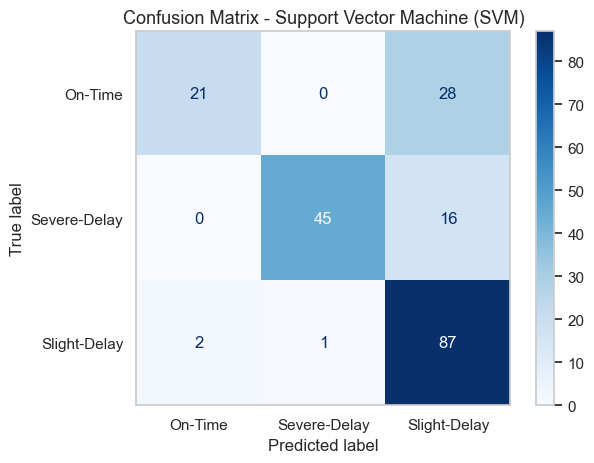

In [12]:
# ==========================================
# Task 3.3: Winner Selection & Test Evaluation
# ==========================================

# Compare CV results and select the best model automatically
if best_logreg_score >= best_svm_score:
    best_classifier = grid_logreg.best_estimator_
    winner_name = "Logistic Regression"
    winner_cv_score = best_logreg_score
else:
    best_classifier = grid_svm.best_estimator_
    winner_name = "Support Vector Machine (SVM)"
    winner_cv_score = best_svm_score

print(f"🏆 Winning Classifier based on CV: {winner_name} (F1-macro: {winner_cv_score:.4f})")

# Evaluate the winning classifier ONCE on locked Test Data
y_class_pred = best_classifier.predict(X_test)

# Calculate final test metrics
acc = accuracy_score(y_class_test, y_class_pred)
prec_macro = precision_score(y_class_test, y_class_pred, average='macro')
rec_macro = recall_score(y_class_test, y_class_pred, average='macro')
f1_macro = f1_score(y_class_test, y_class_pred, average='macro')

print("\n--- Final Test Set Performance (Classification) ---")
print(f"Accuracy:        {acc:.4f}")
print(f"Macro Precision: {prec_macro:.4f}")
print(f"Macro Recall:    {rec_macro:.4f}")
print(f"Macro F1 Score:  {f1_macro:.4f}\n")

# Print full Classification Report
print("--- Full Classification Report ---")
print(classification_report(y_class_test, y_class_pred))

# Display and plot Confusion Matrix (Required Visual)
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_class_test, y_class_pred, labels=best_classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_classifier.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix - {winner_name}", fontsize=13)
plt.grid(False)
plt.tight_layout()
plt.show()

In [13]:
# Setup 5-fold Cross-Validation with shuffling for regression
cv_shuffled = KFold(n_splits=5, shuffle=True, random_state=42)


# ==========================================
# Task 4.1 & 4.2: Models, Search Spaces & GridSearch
# ==========================================

# ------------------------------------------
# Model 1: Linear Regression Pipeline
# ------------------------------------------
linreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Exact hyperparameter grid from brief
linreg_param_grid = {
    'regressor__fit_intercept': [True, False]
}

print("--- Running GridSearch for Linear Regression ---")
grid_linreg = GridSearchCV(
    estimator=linreg_pipeline,
    param_grid=linreg_param_grid,
    cv=cv_shuffled,
    scoring='r2',
    n_jobs=-1
)
grid_linreg.fit(X_train, y_reg_train)

best_linreg_score = grid_linreg.best_score_
print(f"Best Linear Regression CV R2: {best_linreg_score:.4f}")
print(f"Best Params: {grid_linreg.best_params_}\n")




--- Running GridSearch for Linear Regression ---
Best Linear Regression CV R2: 0.9797
Best Params: {'regressor__fit_intercept': False}



In [14]:
# ------------------------------------------
# Model 2: KNN Regressor Pipeline
# ------------------------------------------
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

# Exact hyperparameter grid specs from brief:
# n_neighbors: [5, 9, 15]
# weights: ['uniform', 'distance']
# p: [1, 2] (1=Manhattan, 2=Euclidean)
knn_param_grid = {
    'regressor__n_neighbors': [5, 9, 15],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2]
}

print("--- Running GridSearch for KNN Regressor ---")
grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=cv_shuffled,
    scoring='r2',
    n_jobs=-1
)
grid_knn.fit(X_train, y_reg_train)

best_knn_score = grid_knn.best_score_
print(f"Best KNN Regressor CV R2: {best_knn_score:.4f}")
print(f"Best Params: {grid_knn.best_params_}\n")




--- Running GridSearch for KNN Regressor ---
Best KNN Regressor CV R2: 0.9209
Best Params: {'regressor__n_neighbors': 15, 'regressor__p': 2, 'regressor__weights': 'distance'}



🏆 Winning Regressor based on CV: Linear Regression (R2: 0.9797)

--- Final Test Set Performance (Regression) ---
MAE:      3.3236
RMSE:     4.6288
R-squared:0.9805



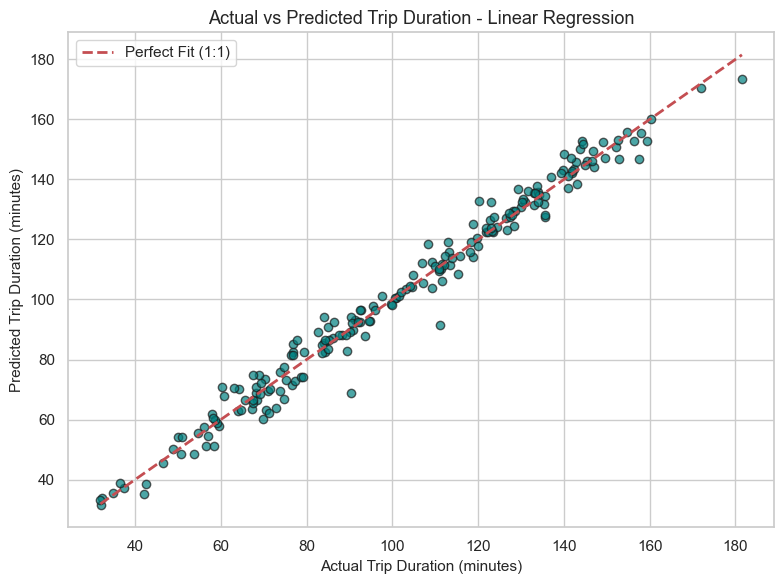

In [15]:
# ==========================================
# Task 4.3: Winner Selection & Test Evaluation
# ==========================================

# Compare CV R2 results and select the best regressor automatically
if best_linreg_score >= best_knn_score:
    best_regressor = grid_linreg.best_estimator_
    winner_reg_name = "Linear Regression"
    winner_reg_cv_score = best_linreg_score
else:
    best_regressor = grid_knn.best_estimator_
    winner_reg_name = "KNN Regressor"
    winner_reg_cv_score = best_knn_score

print(f"🏆 Winning Regressor based on CV: {winner_reg_name} (R2: {winner_reg_cv_score:.4f})")

# Evaluate the winning regressor ONCE on locked Test Data
y_reg_pred = best_regressor.predict(X_test)

# Calculate final test metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

print("\n--- Final Test Set Performance (Regression) ---")
print(f"MAE:      {mae:.4f}")
print(f"RMSE:     {rmse:.4f}")
print(f"R-squared:{r2:.4f}\n")


# Plot Actual vs Predicted Values (Required Visual)
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.7, color='teal', edgecolors='k')
# Plot ideal perfect prediction diagonal line
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', lw=2, label="Perfect Fit (1:1)")
plt.title(f"Actual vs Predicted Trip Duration - {winner_reg_name}", fontsize=13)
plt.xlabel("Actual Trip Duration (minutes)", fontsize=11)
plt.ylabel("Predicted Trip Duration (minutes)", fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Replace 'student_id' with your actual Student ID number/code
STUDENT_ID = "12345"  # <--- Change this to your real student ID!

# ==========================================
# Task 5.1: Save & Reload Selected Models
# ==========================================

# File names according to strict rubric checklist
classifier_filename = f"{STUDENT_ID}_best_bus_delay_classifier.joblib"
regressor_filename = f"{STUDENT_ID}_best_bus_duration_regressor.joblib"

# Save fitted pipelines to disk
joblib.dump(best_classifier, classifier_filename)
joblib.dump(best_regressor, regressor_filename)
print(f" Saved Classifier Model: {classifier_filename}")
print(f" Saved Regressor Model:  {regressor_filename}\n")

# Reload saved models to verify persistence works smoothly
loaded_classifier = joblib.load(classifier_filename)
loaded_regressor = joblib.load(regressor_filename)
print(" Re-loaded both models successfully from disk!\n")




 Saved Classifier Model: 12345_best_bus_delay_classifier.joblib
 Saved Regressor Model:  12345_best_bus_duration_regressor.joblib

 Re-loaded both models successfully from disk!



In [17]:
# ==========================================
# Task 5.2 & 5.3: Predict Unseen Trips (10 Rows)
# ==========================================

# Load the provided 10-row unseen trips CSV
new_trips_df = pd.read_csv("New_Bus_Trips.csv")
print(f"Loaded 'New_Bus_Trips.csv' with shape: {new_trips_df.shape}")

# Ensure we drop trip_id before feeding features to models
X_new = new_trips_df.drop(columns=["trip_id"])

# Generate predictions using the loaded pipelines
predicted_delays = loaded_classifier.predict(X_new)
predicted_durations = loaded_regressor.predict(X_new)

# Construct final required summary table
results_df = pd.DataFrame(
    {
        "trip_id": new_trips_df["trip_id"],
        "predicted_delay_level": predicted_delays,
        "predicted_trip_duration_minutes": predicted_durations.round(2),
    }
)

print("\n--- Final 10 New Trip Predictions ---")
display(results_df)

# Save predictions to CSV for easy copying to Word report
results_df.to_csv(f"{STUDENT_ID}_predictions_output.csv", index=False)

Loaded 'New_Bus_Trips.csv' with shape: (10, 9)

--- Final 10 New Trip Predictions ---


,trip_id,predicted_delay_level,predicted_trip_duration_minutes
0,NEW_TRIP_01,Severe-Delay,60.62
1,NEW_TRIP_02,Severe-Delay,90.05
2,NEW_TRIP_03,Slight-Delay,56.15
3,NEW_TRIP_04,Severe-Delay,63.26
4,NEW_TRIP_05,Severe-Delay,82.88
5,NEW_TRIP_06,On-Time,42.11
6,NEW_TRIP_07,Slight-Delay,50.15
7,NEW_TRIP_08,On-Time,87.51
8,NEW_TRIP_09,Slight-Delay,40.58
9,NEW_TRIP_10,On-Time,77.94
